# DAAN 545 — Flight Delay Analysis
## BTS Airline Delay Cause: Load, Clean, Summarize, Visualize

**Course focus:** data quality, summary statistics, variability/shape/outliers, and visualization.

**Goal:** Load the BTS *Airline Delay Cause* extract, document column definitions, assess cleanliness with reusable helpers, compute summary statistics, create visualizations, and draft findings.

**Data:** `data/raw/Airline_Delay_Cause.csv` with definitions in `data/raw/Download_Column_Definitions.xlsx`.

## 0. Environment & imports

We use **pandas** for wrangling, **numpy/scipy** for stats, and **matplotlib/seaborn** for plots. Cleaning helpers live in `src/cleaning.py` so teammates can reuse them outside this notebook.

In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 25)
pd.set_option("display.width", 120)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (11, 5)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 11

ROOT = Path.cwd()
if not (ROOT / "data" / "raw").exists():
    ROOT = ROOT.parent

DATA_RAW = ROOT / "data" / "raw"
DATA_PROCESSED = ROOT / "data" / "processed"
FIG_DIR = ROOT / "reports" / "figures"

DATA_PROCESSED.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

# Make project helpers importable when the kernel cwd is notebooks/
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.cleaning import (
    CAUSE_COUNT_COLS,
    CAUSE_DELAY_COLS,
    DELAY_MINUTE_COLS,
    clean_delay_cause,
    load_column_definitions,
    load_delay_cause,
    logical_checks,
    missingness_report,
    outlier_summary,
    quality_overview,
    summarize_numeric,
)

print(f"Project root: {ROOT}")
print(f"Raw data dir: {DATA_RAW}")
print(f"Files found: {sorted(p.name for p in DATA_RAW.glob('*') if p.name != '.gitkeep')}")

Project root: C:\Users\MLMir\Projects\DAAN545-flight-delay-analysis
Raw data dir: C:\Users\MLMir\Projects\DAAN545-flight-delay-analysis\data\raw
Files found: ['Airline_Delay_Cause.csv', 'Download_Column_Definitions.xlsx']


## 1. Load data & column definitions

Grain of the table: **one row per carrier × airport × year × month**, with arrival volume plus delay *counts* and delay *minutes* by cause.

In [2]:
CSV_PATH = DATA_RAW / "Airline_Delay_Cause.csv"
DEFS_PATH = DATA_RAW / "Download_Column_Definitions.xlsx"

raw = load_delay_cause(CSV_PATH)
col_defs = load_column_definitions(DEFS_PATH)

print(f"Raw shape: {raw.shape[0]:,} rows × {raw.shape[1]} columns")
print(f"Year span: {raw['year'].min()} → {raw['year'].max()}")
print(f"Carriers: {raw['carrier'].nunique()} | Airports: {raw['airport'].nunique()}")
display(col_defs)
raw.head(3)

Raw shape: 8,963 rows × 21 columns
Year span: 2024 → 2026
Carriers: 21 | Airports: 30


,Column Name,Column Definition
0,year,YYYY format
1,month,MM format (1-12)
2,carrier,Code assigned by assigned by US DOT to identif...
3,carrier_name,Unique airline (carrier) is defined as one hol...
4,airport,A three character alpha-numeric code issued by...
5,airport_name,a place from which aircraft operate that usual...
6,arr_flights,Arrival Flights
7,arr_del15,"Arrival Delay Indicator, 15 Minutes or More Ar..."
8,carrier_ct,Carrier Count for airline cause of delay
9,weather_ct,Weather Count for airline cause of delay


,year,month,carrier,carrier_name,airport,airport_name,arr_flights,arr_del15,carrier_ct,weather_ct,nas_ct,security_ct,late_aircraft_ct,arr_cancelled,arr_diverted,arr_delay,carrier_delay,weather_delay,nas_delay,security_delay,late_aircraft_delay
0,2026,6,MQ,Envoy Air,MSP,"Minneapolis, MN: Minneapolis-St Paul Internati...",85.0000,11.0000,1.6300,0.7000,3.9900,0.0000,4.6800,1.0000,0.0000,614.0000,100.0000,44.0000,146.0000,0.0000,324.0000
1,2026,6,MQ,Envoy Air,ORD,"Chicago, IL: Chicago O'Hare International","4,737.0000",926.0000,188.1100,101.8800,285.3600,2.5200,348.1300,202.0000,17.0000,"85,117.0000","22,441.0000","14,747.0000","19,618.0000",83.0000,"28,228.0000"
2,2026,6,MQ,Envoy Air,PHX,"Phoenix, AZ: Phoenix Sky Harbor International","1,035.0000",168.0000,58.1500,3.8700,21.9800,1.6300,82.3600,1.0000,1.0000,"9,716.0000","3,320.0000",288.0000,895.0000,107.0000,"5,106.0000"


## 2. Data quality checks (is it clean?)

Helpers below report missingness, duplicate keys, logical consistency, and IQR outliers. We **flag** outliers for discussion rather than deleting them automatically — delay minutes are naturally heavy-tailed.

In [3]:
overview = quality_overview(raw)

print("=== Cleanliness snapshot ===")
print(f"Rows / cols: {overview['n_rows']:,} × {overview['n_cols']}")
print(f"Date span:   {overview['date_span']}")
print(f"Carriers / airports: {overview['n_carriers']} / {overview['n_airports']}")
print(f"Total null cells: {overview['total_nulls']} "
      f"(columns with any nulls: {overview['cols_with_nulls']})")
print(f"Duplicate key rows (year-month-carrier-airport): {overview['duplicate_key_rows']}")

print("\nMissingness (columns with nulls first):")
display(overview["missingness"].query("null_count > 0") if overview["total_nulls"] else overview["missingness"].head(8))

print("\nLogical rule flags:")
display(overview["logical_flags"])

=== Cleanliness snapshot ===
Rows / cols: 8,963 × 21
Date span:   2024-01 → 2026-12
Carriers / airports: 21 / 30
Total null cells: 1 (columns with any nulls: 1)
Duplicate key rows (year-month-carrier-airport): 0

Missingness (columns with nulls first):


,null_count,null_pct,dtype,n_rows
arr_del15,1,0.0110,float64,8963



Logical rule flags:


,flagged_rows,flagged_pct
neg_arr_flights,0,0.0000
neg_arr_del15,0,0.0000
del15_gt_flights,0,0.0000
cancel_gt_flights,0,0.0000
divert_gt_flights,0,0.0000
bad_month,0,0.0000
neg_delay_minutes,0,0.0000
cause_sum_mismatch,6,0.0670
delay_sum_mismatch,29,0.3240


In [4]:
# IQR outlier rates on key volume / delay fields (flag-only)
focus_cols = ["arr_flights", "arr_del15", "arr_delay", "pct_delayed"]
# pct_delayed does not exist yet on raw — use delay minutes / counts for now
outliers = outlier_summary(raw, cols=["arr_flights", "arr_del15", "arr_cancelled", "arr_delay", "weather_delay"], k=1.5)
print("IQR outlier summary (k=1.5):")
display(outliers)

IQR outlier summary (k=1.5):


,column,n_non_null,n_outliers_iqr,outlier_pct
0,arr_flights,8963,981,10.9450
1,arr_del15,8962,857,9.5630
2,arr_cancelled,8963,1090,12.1610
3,arr_delay,8963,916,10.2200
4,weather_delay,8963,1037,11.5700


## 3. Clean & engineer features

Steps applied by `clean_delay_cause`:

1. Coerce numeric columns
2. Drop duplicate year–month–carrier–airport keys (keep first)
3. Fill `arr_del15` nulls when `arr_flights == 0`
4. Add `period`, `pct_delayed`, `pct_cancelled`, and average delay minutes per delayed arrival

In [5]:
clean = clean_delay_cause(raw)

print(f"Clean shape: {clean.shape[0]:,} rows × {clean.shape[1]} columns")
print(f"Remaining nulls: {int(clean.isna().sum().sum())}")
print("\nLogical flags after cleaning:")
display(logical_checks(clean))

out_path = DATA_PROCESSED / "airline_delay_cause_clean.csv"
clean.to_csv(out_path, index=False)
print(f"\nSaved cleaned data → {out_path}")
clean.head(3)

Clean shape: 8,963 rows × 27 columns
Remaining nulls: 195

Logical flags after cleaning:


,flagged_rows,flagged_pct
neg_arr_flights,0,0.0000
neg_arr_del15,0,0.0000
del15_gt_flights,0,0.0000
cancel_gt_flights,0,0.0000
divert_gt_flights,0,0.0000
bad_month,0,0.0000
neg_delay_minutes,0,0.0000
cause_sum_mismatch,6,0.0670
delay_sum_mismatch,29,0.3240



Saved cleaned data → C:\Users\MLMir\Projects\DAAN545-flight-delay-analysis\data\processed\airline_delay_cause_clean.csv


,year,month,carrier,carrier_name,airport,airport_name,arr_flights,arr_del15,carrier_ct,weather_ct,nas_ct,security_ct,...,arr_delay,carrier_delay,weather_delay,nas_delay,security_delay,late_aircraft_delay,period,pct_delayed,pct_cancelled,avg_delay_min_per_delayed,cause_count_sum,cause_delay_sum
0,2026,6,MQ,Envoy Air,MSP,"Minneapolis, MN: Minneapolis-St Paul Internati...",85.0000,11.0000,1.6300,0.7000,3.9900,0.0000,...,614.0000,100.0000,44.0000,146.0000,0.0000,324.0000,2026-06-01,12.9412,1.1765,55.8182,11.0000,614.0000
1,2026,6,MQ,Envoy Air,ORD,"Chicago, IL: Chicago O'Hare International","4,737.0000",926.0000,188.1100,101.8800,285.3600,2.5200,...,"85,117.0000","22,441.0000","14,747.0000","19,618.0000",83.0000,"28,228.0000",2026-06-01,19.5482,4.2643,91.9190,926.0000,"85,117.0000"
2,2026,6,MQ,Envoy Air,PHX,"Phoenix, AZ: Phoenix Sky Harbor International","1,035.0000",168.0000,58.1500,3.8700,21.9800,1.6300,...,"9,716.0000","3,320.0000",288.0000,895.0000,107.0000,"5,106.0000",2026-06-01,16.2319,0.0966,57.8333,167.9900,"9,716.0000"


## 4. Summary statistics

Center (mean/median), spread (std / IQR via p25–p75), and shape (skew / excess kurtosis) for the main numeric fields.

In [6]:
stat_cols = [
    "arr_flights", "arr_del15", "arr_cancelled", "arr_diverted",
    "arr_delay", "pct_delayed", "pct_cancelled", "avg_delay_min_per_delayed",
    *CAUSE_DELAY_COLS,
]
stats_tbl = summarize_numeric(clean, cols=stat_cols)
print("Numeric summary statistics")
display(stats_tbl)

# Carrier-level delay rate (weighted by arrivals)
carrier_summary = (
    clean.groupby(["carrier", "carrier_name"], as_index=False)
    .agg(arr_flights=("arr_flights", "sum"),
         arr_del15=("arr_del15", "sum"),
         arr_cancelled=("arr_cancelled", "sum"),
         arr_delay=("arr_delay", "sum"))
)
carrier_summary["pct_delayed"] = 100 * carrier_summary["arr_del15"] / carrier_summary["arr_flights"]
carrier_summary["pct_cancelled"] = 100 * carrier_summary["arr_cancelled"] / carrier_summary["arr_flights"]
carrier_summary = carrier_summary.sort_values("pct_delayed", ascending=False)
print("\nCarrier delay rates (arrival-weighted)")
display(carrier_summary.head(10))

Numeric summary statistics


,n,mean,median,std,min,p25,p75,max,skew,kurtosis
column,,,,,,,,,,
arr_flights,8963,"1,138.3241",426.0000,"1,990.6793",1.0000,109.0000,"1,183.5000","21,854.0000",4.2810,27.5468
arr_del15,8962,241.4297,96.0000,412.9242,0.0000,24.0000,275.0000,"5,544.0000",4.1931,26.4583
arr_cancelled,8963,19.1807,4.0000,54.7601,0.0000,0.0000,15.0000,"1,508.0000",9.7456,167.4017
arr_diverted,8963,3.0861,1.0000,9.1170,0.0000,0.0000,2.0000,232.0000,9.1778,133.4202
arr_delay,8963,"18,449.6955","6,312.0000","35,413.3141",0.0000,"1,488.0000","20,052.0000","648,300.0000",5.4410,47.9550
pct_delayed,8962,22.7900,21.7704,10.3024,0.0000,16.1652,28.2248,100.0000,1.2518,6.4599
pct_cancelled,8963,1.7636,0.8086,2.9064,0.0000,0.0000,2.2690,100.0000,8.1616,190.4232
avg_delay_min_per_delayed,8770,69.4781,66.7213,25.6711,15.0000,54.0000,81.5285,654.6667,4.1422,63.8475
carrier_delay,8963,"6,003.4513","1,912.0000","12,361.9743",0.0000,444.0000,"6,246.0000","321,792.0000",6.5861,82.3678



Carrier delay rates (arrival-weighted)


,carrier,carrier_name,arr_flights,arr_del15,arr_cancelled,arr_delay,pct_delayed,pct_cancelled
6,F9,Frontier Airlines,"333,794.0000","92,887.0000","6,936.0000","7,664,002.0000",27.8276,2.0779
9,HA,Hawaiian Airlines Network,"13,003.0000","3,585.0000",62.0000,"190,695.0000",27.5706,0.4768
8,G7,GoJet Airlines LLC d/b/a United Express,"85,181.0000","21,562.0000","2,571.0000","2,188,980.0000",25.3132,3.0183
3,B6,JetBlue Airways,"349,156.0000","87,987.0000","7,065.0000","6,833,421.0000",25.1999,2.0235
7,G4,Allegiant Air,"39,451.0000","9,878.0000",337.0000,"952,210.0000",25.0387,0.8542
1,AA,American Airlines Network,"1,590,183.0000","376,725.0000","32,559.0000","32,949,597.0000",23.6907,2.0475
11,NK,Spirit Airlines,"307,963.0000","72,799.0000","8,074.0000","5,403,476.0000",23.6389,2.6217
12,OH,PSA Airlines Inc.,"276,761.0000","64,524.0000","11,293.0000","6,474,090.0000",23.3140,4.0804
20,ZW,Air Wisconsin Airlines Corp,"20,761.0000","4,805.0000",253.0000,"504,405.0000",23.1444,1.2186
2,AS,Alaska Airlines Network,"327,364.0000","73,375.0000","3,353.0000","3,816,102.0000",22.4139,1.0242


## 5. Visualization

Plots mirror the Lesson 4 style: distribution/shape, comparison across groups, time trend, and a correlation / composition view. Figures are also saved under `reports/figures/`.

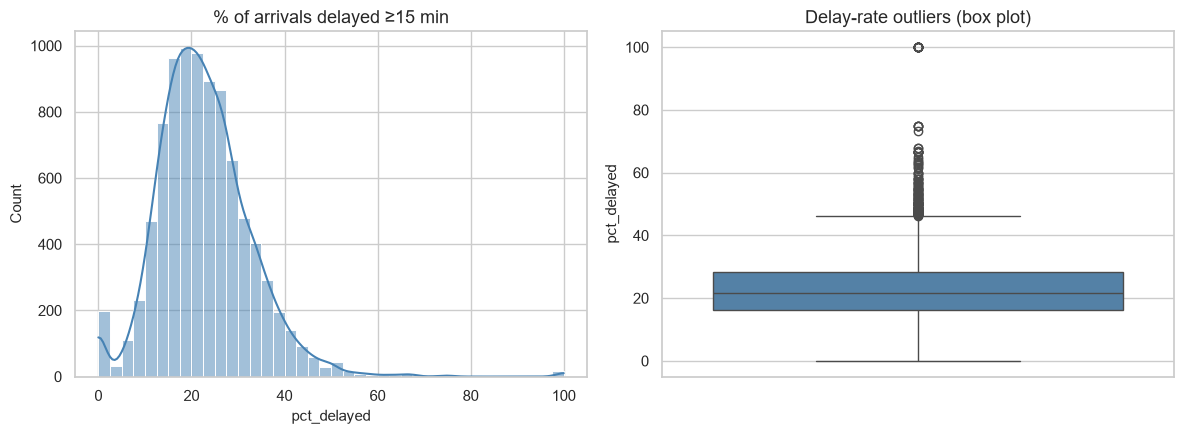

In [7]:
# 5.1 Distribution of airport-carrier monthly delay rates
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

sns.histplot(clean["pct_delayed"].dropna(), bins=40, kde=True, ax=axes[0], color="steelblue")
axes[0].set_title("% of arrivals delayed ≥15 min")
axes[0].set_xlabel("pct_delayed")

sns.boxplot(y=clean["pct_delayed"].dropna(), ax=axes[1], color="steelblue")
axes[1].set_title("Delay-rate outliers (box plot)")
axes[1].set_ylabel("pct_delayed")

fig.tight_layout()
fig.savefig(FIG_DIR / "01_delay_rate_distribution.png", dpi=150)
plt.show()

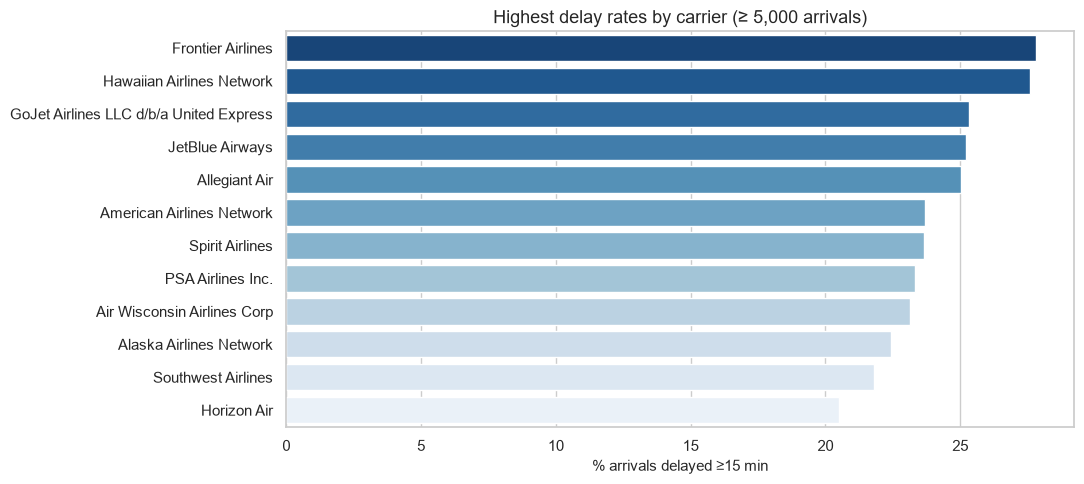

In [8]:
# 5.2 Top carriers by delay rate (min volume filter so tiny samples don't dominate)
min_flights = 5_000
plot_carriers = carrier_summary.query("arr_flights >= @min_flights").head(12)

fig, ax = plt.subplots(figsize=(11, 5))
sns.barplot(
    data=plot_carriers,
    y="carrier_name",
    x="pct_delayed",
    hue="carrier_name",
    legend=False,
    palette="Blues_r",
    ax=ax,
)
ax.set_title(f"Highest delay rates by carrier (≥ {min_flights:,} arrivals)")
ax.set_xlabel("% arrivals delayed ≥15 min")
ax.set_ylabel("")
fig.tight_layout()
fig.savefig(FIG_DIR / "02_carrier_delay_rates.png", dpi=150)
plt.show()

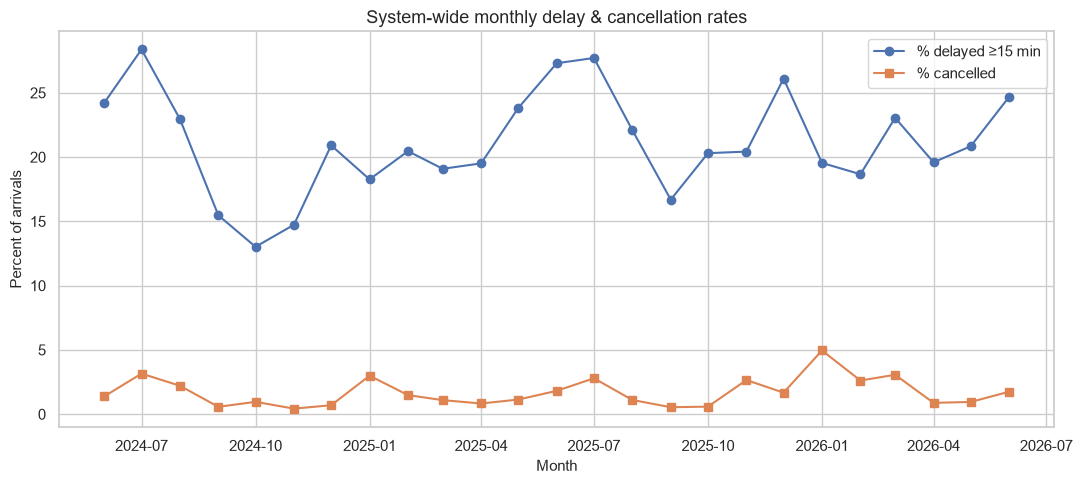

In [9]:
# 5.3 System-wide monthly trend
monthly = (
    clean.groupby("period", as_index=False)
    .agg(arr_flights=("arr_flights", "sum"),
         arr_del15=("arr_del15", "sum"),
         arr_cancelled=("arr_cancelled", "sum"))
)
monthly["pct_delayed"] = 100 * monthly["arr_del15"] / monthly["arr_flights"]
monthly["pct_cancelled"] = 100 * monthly["arr_cancelled"] / monthly["arr_flights"]

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(monthly["period"], monthly["pct_delayed"], marker="o", label="% delayed ≥15 min")
ax.plot(monthly["period"], monthly["pct_cancelled"], marker="s", label="% cancelled")
ax.set_title("System-wide monthly delay & cancellation rates")
ax.set_xlabel("Month")
ax.set_ylabel("Percent of arrivals")
ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / "03_monthly_delay_trend.png", dpi=150)
plt.show()

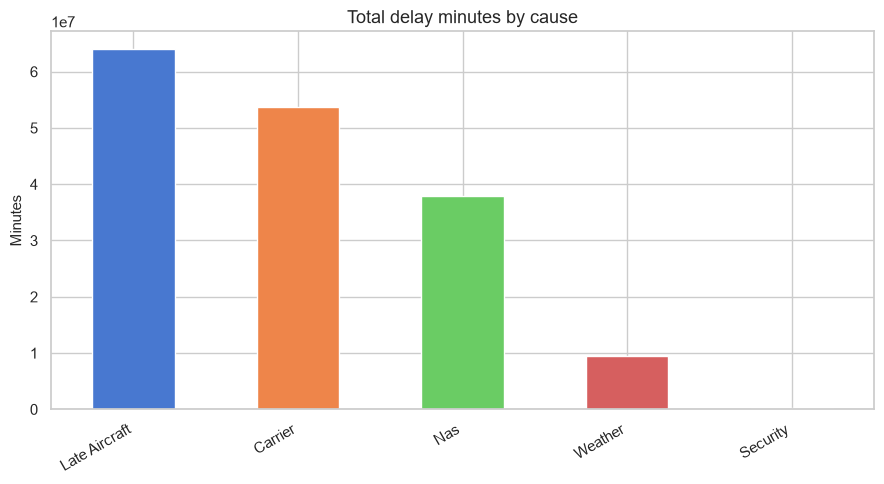

,share_pct
Late Aircraft,38.6715
Carrier,32.5409
Nas,22.9033
Weather,5.7566
Security,0.1277


In [10]:
# 5.4 Delay-cause composition (minutes)
cause_totals = clean[CAUSE_DELAY_COLS].sum().sort_values(ascending=False)
cause_totals.index = [
    c.replace("_delay", "").replace("_", " ").title()
    for c in cause_totals.index
]

fig, ax = plt.subplots(figsize=(9, 5))
cause_totals.plot(kind="bar", ax=ax, color=sns.color_palette("muted", len(cause_totals)))
ax.set_title("Total delay minutes by cause")
ax.set_ylabel("Minutes")
ax.set_xlabel("")
plt.xticks(rotation=30, ha="right")
fig.tight_layout()
fig.savefig(FIG_DIR / "04_delay_cause_minutes.png", dpi=150)
plt.show()

display((100 * cause_totals / cause_totals.sum()).rename("share_pct").to_frame())

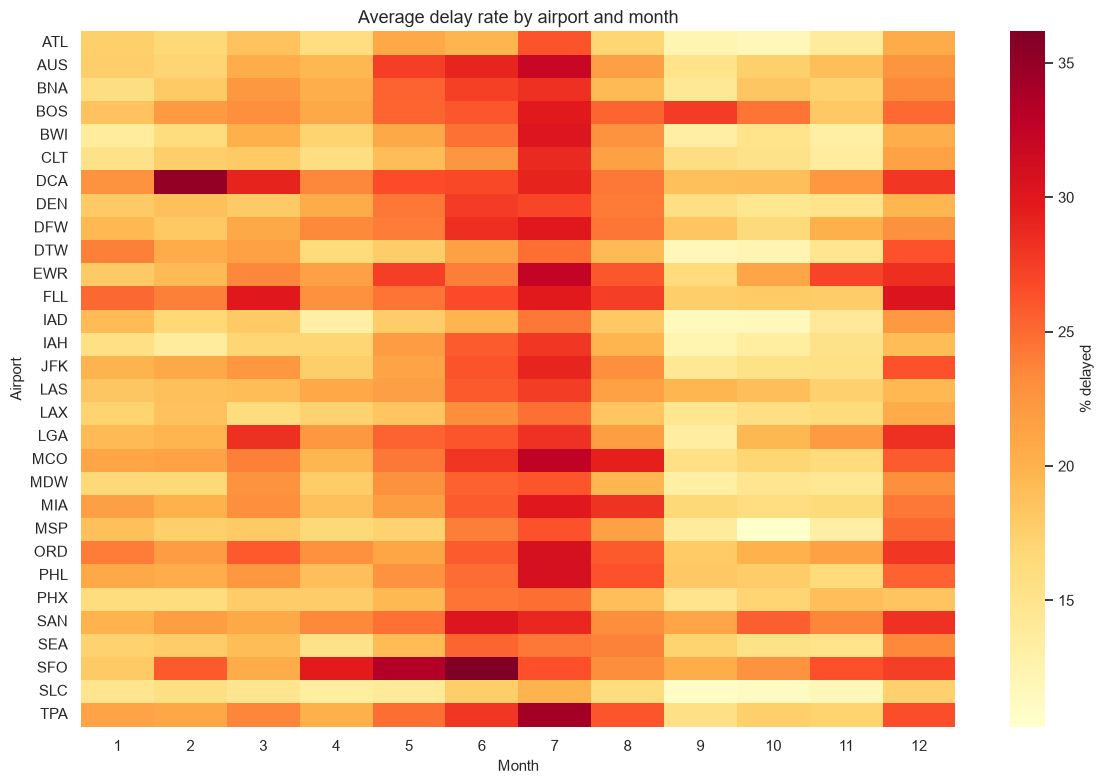

In [11]:
# 5.5 Airport heatmap: mean delay rate by airport × month-of-year
airport_month = (
    clean.groupby(["airport", "month"], as_index=False)
    .apply(
        lambda g: pd.Series({
            "pct_delayed": 100 * g["arr_del15"].sum() / g["arr_flights"].sum()
        }),
        include_groups=False,
    )
)
# pandas groupby.apply can return MultiIndex depending on version — normalize
if isinstance(airport_month.index, pd.MultiIndex):
    airport_month = airport_month.reset_index()

heat = airport_month.pivot(index="airport", columns="month", values="pct_delayed")

fig, ax = plt.subplots(figsize=(12, 8))
sns.heatmap(heat, cmap="YlOrRd", ax=ax, cbar_kws={"label": "% delayed"})
ax.set_title("Average delay rate by airport and month")
ax.set_xlabel("Month")
ax.set_ylabel("Airport")
fig.tight_layout()
fig.savefig(FIG_DIR / "05_airport_month_heatmap.png", dpi=150)
plt.show()

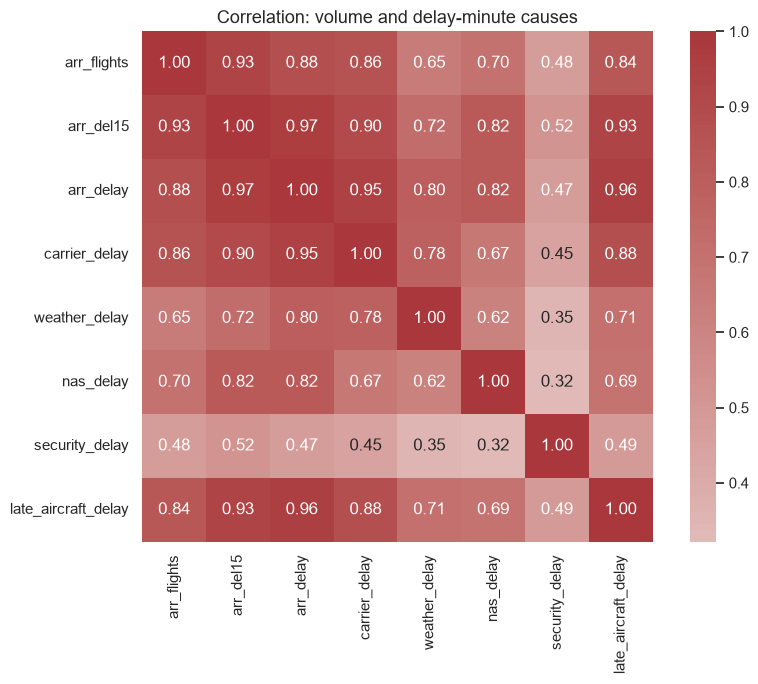

In [12]:
# 5.6 Correlation among delay-minute causes + volume
corr_cols = ["arr_flights", "arr_del15", "arr_delay", *CAUSE_DELAY_COLS]
corr = clean[corr_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="vlag", center=0, ax=ax, square=True)
ax.set_title("Correlation: volume and delay-minute causes")
fig.tight_layout()
fig.savefig(FIG_DIR / "06_delay_correlation.png", dpi=150)
plt.show()

## 6. Brief findings (draft notes)

Use these bullets as a starting point for a written report — expand in your own words.

In [13]:
top_airports = (
    clean.groupby(["airport", "airport_name"], as_index=False)
    .agg(arr_flights=("arr_flights", "sum"), arr_del15=("arr_del15", "sum"))
)
top_airports["pct_delayed"] = 100 * top_airports["arr_del15"] / top_airports["arr_flights"]
top_airports = top_airports.sort_values("pct_delayed", ascending=False)

cause_share = 100 * clean[CAUSE_DELAY_COLS].sum() / clean[CAUSE_DELAY_COLS].sum().sum()
peak_month = monthly.loc[monthly["pct_delayed"].idxmax()]

print("=== Draft insights (edit for your report) ===\n")
print(f"1. Panel covers {overview['date_span']} for "
      f"{overview['n_carriers']} carriers and {overview['n_airports']} airports "
      f"({overview['n_rows']:,} carrier-airport-months).")
print(f"2. Data quality: {overview['total_nulls']} null cell(s) in raw; "
      f"{overview['duplicate_key_rows']} duplicate key rows; "
      f"after cleaning remaining nulls = {int(clean.isna().sum().sum())}.")
print(f"3. Peak system delay month: {peak_month['period'].strftime('%Y-%m')} "
      f"at {peak_month['pct_delayed']:.1f}% delayed.")
print("4. Delay-minute cause shares:")
for col, share in cause_share.sort_values(ascending=False).items():
    print(f"   - {col}: {share:.1f}%")
print("5. Highest airport delay rates (arrival-weighted):")
for _, row in top_airports.head(3).iterrows():
    print(f"   - {row['airport']} ({row['airport_name']}): {row['pct_delayed']:.1f}%")
print("6. Delay-rate distribution is right-skewed with high-volume hubs pulling long tails — "
      "IQR outliers are expected; treat as flags, not automatic deletes.")

=== Draft insights (edit for your report) ===

1. Panel covers 2024-01 → 2026-12 for 21 carriers and 30 airports (8,963 carrier-airport-months).
2. Data quality: 1 null cell(s) in raw; 0 duplicate key rows; after cleaning remaining nulls = 195.
3. Peak system delay month: 2024-07 at 28.4% delayed.
4. Delay-minute cause shares:
   - late_aircraft_delay: 38.7%
   - carrier_delay: 32.5%
   - nas_delay: 22.9%
   - weather_delay: 5.8%
   - security_delay: 0.1%
5. Highest airport delay rates (arrival-weighted):
   - SFO (San Francisco, CA: San Francisco International): 26.4%
   - DCA (Washington, DC: Ronald Reagan Washington National): 25.5%
   - FLL (Fort Lauderdale, FL: Fort Lauderdale-Hollywood International): 24.9%
6. Delay-rate distribution is right-skewed with high-volume hubs pulling long tails — IQR outliers are expected; treat as flags, not automatic deletes.


## 7. Reproducibility checklist

- [ ] Raw CSV + column definitions in `data/raw/`
- [ ] Project `.venv` created and `pip install -r requirements.txt`
- [ ] Kernel restarted & notebook run top-to-bottom
- [ ] Figures saved under `reports/figures/`
- [ ] Cleaned data saved under `data/processed/`
- [ ] Written report describes cleaning, summary stats, and visualization insights (no code dumps)